[Reference](https://medium.com/@katherineolowookere/barebone-implementation-of-every-transformer-component-9d7ab56aa9e2)

In [1]:
import torch
import torch as t
import torch.nn as nn
import numpy as np
import math

#Config Class
# hyperparameters for the model
class Config:
    d_model: int = 64  # Dimension of the model's intermediate vectors
    d_head: int = 32   # Dimension of the attention head's vectors
    n_heads: int = 2   # Number of attention heads
    n_layers: int = 1  # Number of decoder blocks
    d_vocab: int = 100 # Size of the vocabulary
    n_ctx: int = 10    # Max sequence context length
    d_mlp: int = 256   # Dimension of the MLP hidden layer (4 * d_model in tiny model)
    init_range: float = 0.02

    def __init__(self, **kwargs):
        for k, v in kwargs.items():
            setattr(self, k, v)

cfg = Config()
device = 'cuda' if torch.cuda.is_available() else 'cpu'

Int = lambda tensor, dims: tensor
Float = lambda tensor, dims: tensor

### Positional Embedding

In [2]:
class Embed(nn.Module):
    def __init__(self, cfg: Config):
        super().__init__()
        self.W_E = nn.Parameter(t.empty((cfg.d_vocab, cfg.d_model)))
        nn.init.normal_(self.W_E, std=cfg.init_range)

    def forward(self, tokens: t.Tensor) -> t.Tensor:
        return self.W_E[tokens]

# I'm using the simpler Learned Positional Embedding for this minimal script. The original Transformer paper used sinusodal encodings
class Learned_PosEmbed(nn.Module):
    def __init__(self, cfg: Config):
        super().__init__()
        self.W_pos = nn.Parameter(t.empty((cfg.n_ctx, cfg.d_model)))
        nn.init.normal_(self.W_pos, std=cfg.init_range)

    def forward(self, tokens: t.Tensor) -> t.Tensor:
        T = tokens.shape[1]
        position_tokens = torch.arange(T, device=tokens.device)
        return self.W_pos[position_tokens]

### MultiHead Attention with Causal Masking

In [3]:
class Attention(nn.Module):
    def __init__(self, cfg: Config):
        super().__init__()
        self.cfg = cfg
        # Define Q, K, V, O weight matrices and biases
        self.W_Q = nn.Parameter(t.empty((cfg.n_heads, cfg.d_model, cfg.d_head)))
        self.W_K = nn.Parameter(t.empty((cfg.n_heads, cfg.d_model, cfg.d_head)))
        self.W_V = nn.Parameter(t.empty((cfg.n_heads, cfg.d_model, cfg.d_head)))
        self.W_O = nn.Parameter(t.empty((cfg.n_heads, cfg.d_head, cfg.d_model)))

        self.b_Q = nn.Parameter(t.zeros((cfg.n_heads, cfg.d_head)))
        self.b_K = nn.Parameter(t.zeros((cfg.n_heads, cfg.d_head)))
        self.b_V = nn.Parameter(t.zeros((cfg.n_heads, cfg.d_head)))
        self.b_O = nn.Parameter(t.zeros((cfg.d_model)))

        # Initialize weights
        for param in [self.W_Q, self.W_K, self.W_V, self.W_O]:
            nn.init.normal_(param, std=cfg.init_range)

        self.register_buffer("IGNORE", t.tensor(float("-inf"), dtype=t.float32, device=device))

        # Store attention weights for visualization
        self.attn_weights = None

    def apply_causal_mask(self, attn_scores):
        B, H, Q, K = attn_scores.shape
        causal_mask = torch.triu(torch.full((Q, K), fill_value=self.IGNORE), diagonal=1).to(attn_scores.device)
        return attn_scores + causal_mask

    def forward(self, normalized_resid_pre):
        B, T, D_MODEL = normalized_resid_pre.shape
        D_HEAD = self.cfg.d_head
        N_HEADS = self.cfg.n_heads

        # Project to Q, K, V using clearer einsum notation
        Q = t.einsum("b t d, h d m -> b h t m", normalized_resid_pre, self.W_Q) + self.b_Q.unsqueeze(0).unsqueeze(2)
        K = t.einsum("b t d, h d m -> b h t m", normalized_resid_pre, self.W_K) + self.b_K.unsqueeze(0).unsqueeze(2)
        V = t.einsum("b t d, h d m -> b h t m", normalized_resid_pre, self.W_V) + self.b_V.unsqueeze(0).unsqueeze(2)

        # Calculate Attention Scores (bhqm, bhkm -> bhqk) - using q and k for query/key sequence length
        attn_scores = t.einsum("bhqm, bhkm -> bhqk", Q, K) / (D_HEAD**0.5)

        # Apply Causal Mask
        attn_scores = self.apply_causal_mask(attn_scores)

        # Softmax to get Weights
        attn_weights = attn_scores.softmax(dim=-1)

        # Store Weights for Visualization
        self.attn_weights = attn_weights.detach().cpu().numpy()

        # Weighted Sum of Values (bhqk, bhkv -> bhqv) - using q and v for query/value sequence length
        # Here k and v sequence lengths are the same as q (T), and the dimension summed over is k.
        # The value dimension is d_head.
        outputs_per_head = t.einsum("bhqk, bhkv -> bhqv", attn_weights, V)


        # Final Linear Projection (W_O) - sum over heads and d_head
        # outputs_per_head shape: (B, n_heads, T, d_head) -> (b, h, t, m)
        # self.W_O shape: (n_heads, d_head, d_model) -> (h, m, o)
        # Desired output shape: (B, T, d_model) -> (b, t, o)
        output = t.einsum("b h t m, h m o -> b t o", outputs_per_head, self.W_O) + self.b_O.unsqueeze(0).unsqueeze(0)


        return output

### Multi-Layer Perceptron (FFN)

In [4]:
class MLP(nn.Module):
    def __init__(self, cfg: Config):
        super().__init__()
        self.W_in = nn.Parameter(t.empty((cfg.d_model, cfg.d_mlp)))
        self.W_out = nn.Parameter(t.empty((cfg.d_mlp, cfg.d_model)))
        self.b_in = nn.Parameter(t.zeros((cfg.d_mlp)))
        self.b_out = nn.Parameter(t.zeros((cfg.d_model)))
        nn.init.normal_(self.W_in, std=cfg.init_range)
        nn.init.normal_(self.W_out, std=cfg.init_range)
        self.gelu = nn.GELU()

    def forward(self, normalized_resid_mid):

        x = normalized_resid_mid @ self.W_in + self.b_in
        x = self.gelu(x)
        x = x @ self.W_out + self.b_out
        return x

### LayerNorm and Residual Stream (Pre-Norm Block)

In [5]:
class DecoderBlock(nn.Module):
    def __init__(self, cfg: Config):
        super().__init__()
        self.attn = Attention(cfg)
        self.mlp = MLP(cfg)
        self.ln1 = nn.LayerNorm(cfg.d_model)
        self.ln2 = nn.LayerNorm(cfg.d_model)

    def forward(self, x):
        # Pre-Norm + Attention + Residual Connection
        normalized_x = self.ln1(x)
        attn_out = self.attn(normalized_x)
        x = x + attn_out # Residual connection for Attention

        # Pre-Norm + FFN + Residual Connection
        normalized_x = self.ln2(x)
        mlp_out = self.mlp(normalized_x)
        x = x + mlp_out # Residual connection for FFN

        return x

### Full Decoder Model

In [6]:
class Decoder(nn.Module):
    def __init__(self, cfg: Config):
        super().__init__()
        self.embed = Embed(cfg)
        self.pos_embed = Learned_PosEmbed(cfg)
        self.blocks = nn.ModuleList([DecoderBlock(cfg) for _ in range(cfg.n_layers)])
        self.ln_final = nn.LayerNorm(cfg.d_model)
        self.unembed = nn.Linear(cfg.d_model, cfg.d_vocab, bias=False) # Final layer to logits

    def forward(self, tokens):
        # Embedding + Positional Encoding
        x = self.embed(tokens) + self.pos_embed(tokens)

        # Sequential Blocks
        for block in self.blocks:
            x = block(x)

        #Final Layer Norm and Unembedding to Logits
        x = self.ln_final(x)
        logits = self.unembed(x)

        return logits

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

def visualize_attention(model: Decoder, tokens: list[str], layer_index: int = 0, figsize=(8 * cfg.n_heads, 8)):
    """
    Runs the model and visualizes the attention weights for a given layer.

    Args:
        model: The trained or initialized Decoder model.
        tokens: The list of string tokens used as input.
        layer_index: The index of the decoder block to visualize.
        figsize: The size of the figure (width, height) in inches.
    """
    model.eval()

    attn_module = model.blocks[layer_index].attn

    # Run a forward pass to populate the attn_weights buffer
    input_ids = torch.tensor([[i for i in range(len(tokens))]]) # Dummy IDs for the tokens
    model(input_ids)

    if attn_module.attn_weights is None:
        print("Error: No attention weights recorded. Ensure the model ran successfully.")
        return

    attn_weights = attn_module.attn_weights[0]
    n_heads = attn_weights.shape[0]

    fig, axes = plt.subplots(1, n_heads, figsize=figsize)
    if n_heads == 1:
        axes = [axes]

    fig.suptitle(f'Attention Weights in Layer {layer_index}', fontsize=16)

    for h in range(n_heads):
        # Apply the attention weights plot
        sns.heatmap(
            attn_weights[h],
            ax=axes[h],
            vmin=0,
            vmax=1,
            annot=True,
            fmt=".2f",
            cmap="viridis",
            xticklabels=tokens,
            yticklabels=tokens
        )
        axes[h].set_title(f'Head {h}')
        axes[h].set_ylabel('Q_Position')
        axes[h].set_xlabel('K_Position')

    plt.tight_layout(rect=[0, 0.03, 1, 1])
    plt.show()

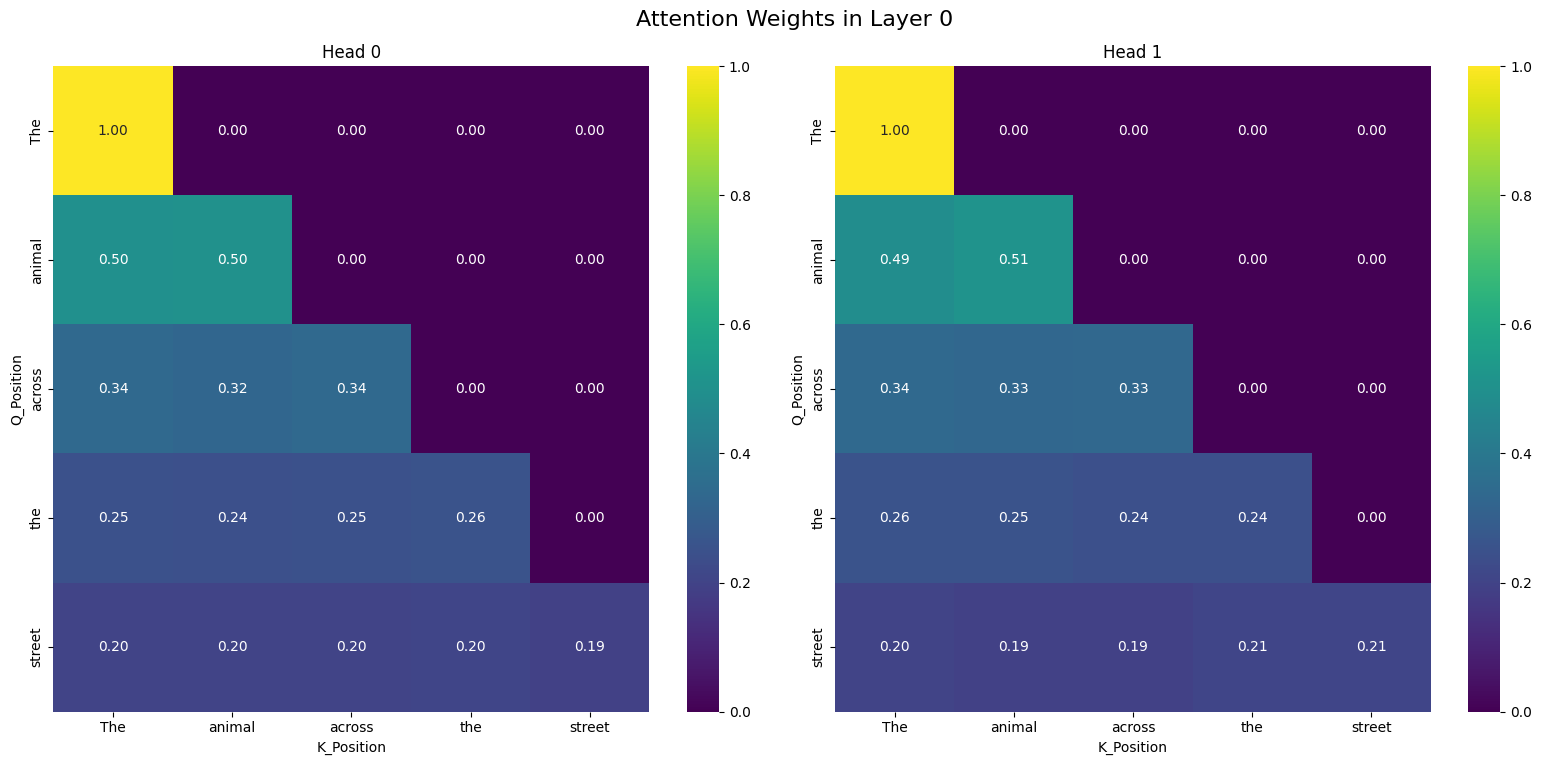

In [9]:
model = Decoder(cfg)
tokens = ["The", "animal", "across", "the", "street"]
visualize_attention(model, tokens, layer_index=0)